In [1]:
%pip -q install pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import re, json
import pandas as pd
import matplotlib.pyplot as plt


## Validating M/D/1 Queue Theory (from perf_analyzer stdout)

This notebook parses Triton `perf_analyzer` stdout logs (`rps_*.stdout.txt`) and compares the **measured server queue time** to the **M/D/1 theoretical queue time** as a function of utilization ρ.


In [3]:
# ---- Point this at your run folder ----
RUN_DIR =  Path.home()/'results/food_classifier_onnx_poisson_no_batch_100-500rps_20260314T223208Z'
RAW_DIR = RUN_DIR / 'perf_raw'

stdout_files = sorted(RAW_DIR.glob('rps_*.stdout.txt'))
print('Found', len(stdout_files), 'files under', RAW_DIR)
stdout_files[:3]


Found 9 files under /home/jovyan/results/food_classifier_onnx_poisson_no_batch_100-500rps_20260314T223208Z/perf_raw


[PosixPath('/home/jovyan/results/food_classifier_onnx_poisson_no_batch_100-500rps_20260314T223208Z/perf_raw/rps_100.stdout.txt'),
 PosixPath('/home/jovyan/results/food_classifier_onnx_poisson_no_batch_100-500rps_20260314T223208Z/perf_raw/rps_150.stdout.txt'),
 PosixPath('/home/jovyan/results/food_classifier_onnx_poisson_no_batch_100-500rps_20260314T223208Z/perf_raw/rps_200.stdout.txt')]

In [4]:
def _find_float(pattern: str, text: str):
    m = re.search(pattern, text, re.MULTILINE)
    return float(m.group(1)) if m else None

def _find_int(pattern: str, text: str):
    m = re.search(pattern, text, re.MULTILINE)
    return int(m.group(1)) if m else None

def parse_perf_analyzer_stdout(text: str) -> dict:
    d = {}
    # Target offered load
    d['Request Rate'] = _find_float(r"Request Rate:\s+([0-9.]+)\s+inference requests per second", text)
    # Throughput
    d['Inferences/Second'] = _find_float(r"Throughput:\s+([0-9.]+)\s+infer/sec", text)
    # Server queue time (usec)
    d['Server Queue'] = _find_float(r"queue\s+([0-9.]+)\s+usec", text)
    d['Client p99 latency (usec)'] = _find_float(r"p99 latency:\s+([0-9.]+)\s+usec", text)
    d['Client delayed %'] = _find_float(r"(\d+(?:\.\d+)?)% of the requests were delayed", text)
    d['Batch size'] = _find_int(r"Batch size:\s+(\d+)", text)
    return d

In [5]:
print("Raw directory:", RAW_DIR)
print("Files found:", len(stdout_files))
stdout_files[:5]

Raw directory: /home/jovyan/results/food_classifier_onnx_poisson_no_batch_100-500rps_20260314T223208Z/perf_raw
Files found: 9


[PosixPath('/home/jovyan/results/food_classifier_onnx_poisson_no_batch_100-500rps_20260314T223208Z/perf_raw/rps_100.stdout.txt'),
 PosixPath('/home/jovyan/results/food_classifier_onnx_poisson_no_batch_100-500rps_20260314T223208Z/perf_raw/rps_150.stdout.txt'),
 PosixPath('/home/jovyan/results/food_classifier_onnx_poisson_no_batch_100-500rps_20260314T223208Z/perf_raw/rps_200.stdout.txt'),
 PosixPath('/home/jovyan/results/food_classifier_onnx_poisson_no_batch_100-500rps_20260314T223208Z/perf_raw/rps_250.stdout.txt'),
 PosixPath('/home/jovyan/results/food_classifier_onnx_poisson_no_batch_100-500rps_20260314T223208Z/perf_raw/rps_300.stdout.txt')]

In [6]:
rows = []
for f in stdout_files:
    txt = f.read_text(errors='replace')
    d = parse_perf_analyzer_stdout(txt)
    # Fall back to filename if needed
    m = re.search(r"rps_(\d+)\.stdout\.txt$", f.name)
    if d.get('Request Rate') is None and m:
        d['Request Rate'] = float(m.group(1))
    d['file'] = f.name
    rows.append(d)

df = pd.DataFrame(rows)
df = df.sort_values('Request Rate').reset_index(drop=True)
print(df.head())

# Save a summary CSV (optional)
out_csv = RUN_DIR / 'perf_summary.csv'
df.to_csv(out_csv, index=False)
print('Wrote', out_csv)

   Request Rate  Inferences/Second  Server Queue  Client p99 latency (usec)  \
0         100.0            100.851        1245.0                    16934.0   
1         150.0            149.766        2680.0                    23123.0   
2         200.0            200.052        3685.0                    27363.0   
3         250.0            250.147        4425.0                    28152.0   
4         300.0            299.299        3952.0                    27462.0   

   Client delayed %  Batch size                file  
0               NaN           1  rps_100.stdout.txt  
1               NaN           1  rps_150.stdout.txt  
2               NaN           1  rps_200.stdout.txt  
3               NaN           1  rps_250.stdout.txt  
4               NaN           1  rps_300.stdout.txt  
Wrote /home/jovyan/results/food_classifier_onnx_poisson_no_batch_100-500rps_20260314T223208Z/perf_summary.csv


In [7]:
# estimate mu as the *peak observed throughput
max_serv_rate = float(df['Inferences/Second'].max())
print('Estimated max service rate (mu) =', max_serv_rate, 'infer/sec')

df['Rho Values'] = df['Request Rate'] / max_serv_rate

# Guard against rho>=1 (the theory blows up)
#df['Rho Values'] = df['Rho Values'].clip(upper=0.9999)

# ---- M/D/1 theory queue time (microseconds) ----
# Wq = rho / (2*mu*(1-rho))  [seconds]  -> multiply by 1e6 to get usec
df['Theory Queue Time'] = (1e6) * df['Rho Values'] / (2 * max_serv_rate * (1 - df['Rho Values']))

df[['Request Rate','Inferences/Second','Server Queue','Rho Values','Theory Queue Time']].head()


Estimated max service rate (mu) = 455.78 infer/sec


,Request Rate,Inferences/Second,Server Queue,Rho Values,Theory Queue Time
0,100.0,100.851,1245.0,0.219404,308.342372
1,150.0,149.766,2680.0,0.329106,538.142043
2,200.0,200.052,3685.0,0.438808,857.784418
3,250.0,250.147,4425.0,0.548510,1332.758884
4,300.0,299.299,3952.0,0.658212,2112.634149


In [8]:
df[['Request Rate','Inferences/Second','Server Queue','Rho Values','Theory Queue Time']]

,Request Rate,Inferences/Second,Server Queue,Rho Values,Theory Queue Time
0,100.0,100.851,1245.0,0.219404,308.342372
1,150.0,149.766,2680.0,0.329106,538.142043
2,200.0,200.052,3685.0,0.438808,857.784418
3,250.0,250.147,4425.0,0.548510,1332.758884
4,300.0,299.299,3952.0,0.658212,2112.634149
5,350.0,354.676,4041.0,0.767914,3629.770962
6,400.0,402.778,5470.0,0.877616,7866.765811
7,450.0,455.780,14482.0,0.987318,85408.169819
8,500.0,NaN,NaN,1.097020,-12404.121352


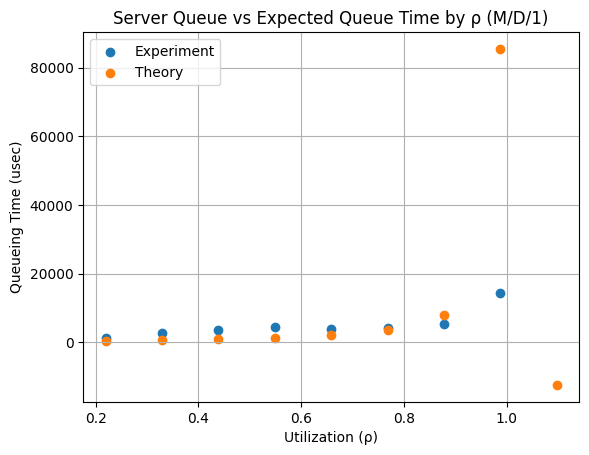

In [9]:
# Plot: measured server queue vs theory
fig, ax = plt.subplots()

ax.scatter(df['Rho Values'], df['Server Queue'], label='Experiment')
ax.scatter(df['Rho Values'], df['Theory Queue Time'], label='Theory')

ax.set_title('Server Queue vs Expected Queue Time by ρ (M/D/1)')
ax.set_xlabel('Utilization (ρ)')
ax.set_ylabel('Queueing Time (usec)')
ax.legend()
ax.grid(True)
plt.show()


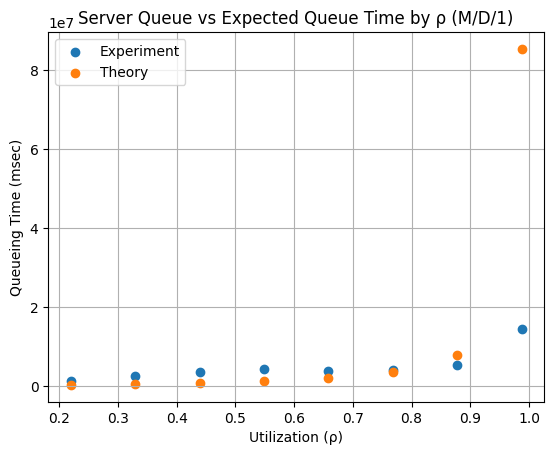

In [12]:
# Plot: measured server queue vs theory
fig, ax = plt.subplots()

ax.scatter(df["Rho Values"][:-1], df["Server Queue"][:-1]*1000, label="Experiment")
ax.scatter(df["Rho Values"][:-1], df["Theory Queue Time"][:-1]*1000, label="Theory")

ax.set_title('Server Queue vs Expected Queue Time by ρ (M/D/1)')
ax.set_xlabel('Utilization (ρ)')
ax.set_ylabel('Queueing Time (msec)')
ax.legend()
ax.grid(True)
plt.savefig(RAW_DIR / "queue_vs_theory_plot.png", dpi=300, bbox_inches="tight")
plt.show()

Save dataframe in a json for later use.

In [13]:
df.to_json(RAW_DIR / "queue_vs_theory_data_full.json", orient="records", indent=2)